# 🤖 Machine-Learning Trading Signal with Alpaca (Paper Trading Only)

**Homework 3.** Build a simple ML trading signal on Alpaca market data,
evaluate it with a backtest, and demo it in Alpaca's **paper** environment.

> ⚠️ **This is PAPER TRADING ONLY — no real money is used.**

Pipeline: **Data → Features → PCA → ML model → Signal → Backtest → Metrics → Paper trade.**


In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd

from src.data import get_daily_ohlcv
from src.features import build_features, FEATURE_COLUMNS
from src.model import train_signal_model
from src.backtest import run_backtest
from src.metrics import metrics_table
from src.plotting import (plot_pca_variance, plot_equity_curves,
                          plot_drawdowns, plot_signal)

TICKER = "AAPL"      # try MSFT, SPY, QQQ, NVDA …
MODEL  = "random_forest"
THRESHOLD = 0.60
print("Config:", TICKER, MODEL, "threshold", THRESHOLD)

Config: AAPL random_forest threshold 0.6


## 1 · Data Collection — 5 years of daily OHLCV from Alpaca

In [2]:
df = get_daily_ohlcv(TICKER, years=5)
print(f"{len(df)} bars: {df.index[0].date()} -> {df.index[-1].date()}")
df.tail()

1257 bars: 2021-07-06 -> 2026-07-08


,open,high,low,close,volume
date,,,,,
2026-07-01 04:00:00,293.440,296.570,289.195,294.420,2428489.0
2026-07-02 04:00:00,294.085,309.415,293.890,308.235,3813037.0
2026-07-06 04:00:00,307.540,314.190,307.020,312.730,1434853.0
2026-07-07 04:00:00,315.290,315.470,310.180,310.690,1573402.0
2026-07-08 04:00:00,311.910,314.805,307.110,313.330,1549372.0


## 2 · Feature Engineering

11 indicators (trend / momentum / volatility / volume) + **log returns** + **rolling mean & std**.

In [3]:
feat = build_features(df)
print(f"{len(FEATURE_COLUMNS)} feature columns")
feat[FEATURE_COLUMNS].tail()

29 feature columns


,sma20,sma50,ema20,ema50,ema200,macd,macd_signal,macd_hist,adx,plus_di,...,atr,obv,cmf,log_return,roll_mean_5,roll_mean_10,roll_mean_20,roll_std_5,roll_std_10,roll_std_20
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 04:00:00,294.75175,292.6136,292.741530,289.754300,268.519704,-2.347352,-1.085213,-1.262139,24.386778,18.861078,...,8.169221,35233882.0,-0.334610,0.017751,0.000749,-0.001631,-0.003409,0.037269,0.025344,0.021341
2026-07-02 04:00:00,294.65250,293.4551,294.217098,290.479033,268.914881,-0.776524,-1.023475,0.246951,23.736374,27.007989,...,8.694634,39046919.0,-0.221144,0.045855,0.022666,0.004027,-0.000321,0.016056,0.029123,0.023768
2026-07-06 04:00:00,294.72850,294.2469,295.980232,291.351620,269.350852,0.821606,-0.654459,1.476065,23.632897,29.369488,...,8.585732,40481772.0,-0.196902,0.014478,0.021177,0.004872,0.000244,0.016481,0.029309,0.023989
2026-07-07 04:00:00,294.88350,294.9909,297.381162,292.109988,269.762187,1.901604,-0.143246,2.044851,23.666248,29.135411,...,8.350322,38908370.0,-0.184432,-0.006545,0.019598,0.004557,0.000501,0.019036,0.029425,0.023881
2026-07-08 04:00:00,295.47150,295.8367,298.900099,292.942146,270.195697,2.936684,0.472740,2.463944,23.193652,27.206822,...,8.303514,40457742.0,-0.107725,0.008461,0.016000,0.006273,0.001913,0.019117,0.029064,0.023451


## 3 · PCA

Standardize the features and keep the components explaining **≥80%** of the variance. PCA is fit on the **training window only** (no look-ahead).

Kept 4 components — 83.4% variance


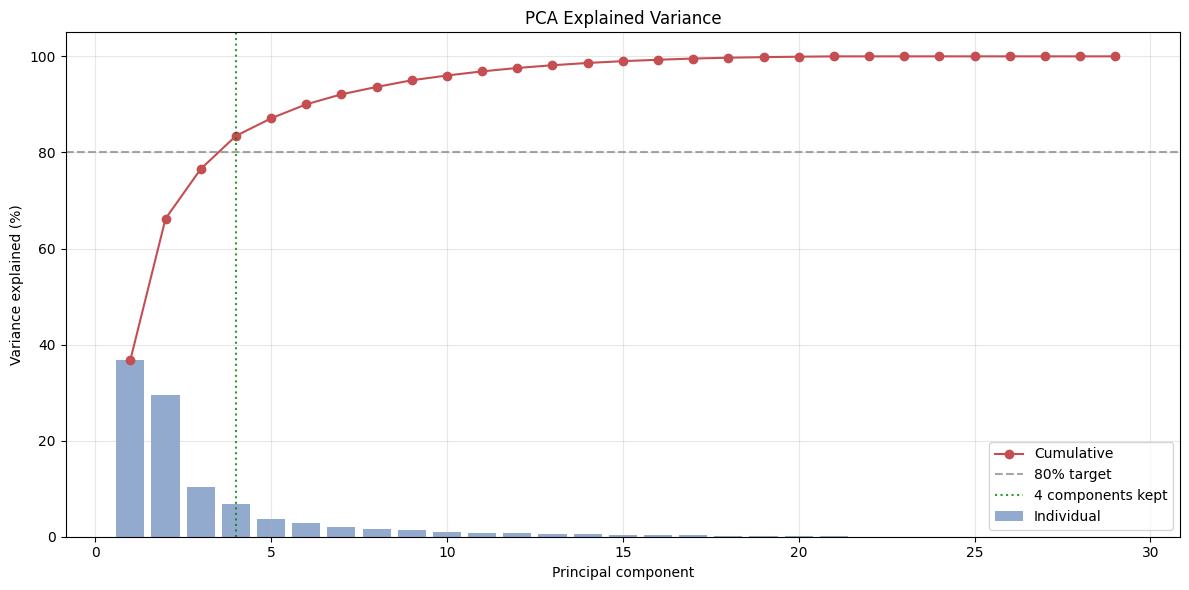

In [4]:
sm = train_signal_model(df, model=MODEL, threshold=THRESHOLD)
kept = sm.pca.n_components
print(f"Kept {kept} components — "
      f"{sm.pca.explained_variance_ratio[:kept].sum()*100:.1f}% variance")
fig = plot_pca_variance(sm.pca); plt.show()

## 4 · ML Model & Signal

Target = **next-day return > 0**. Signal = **Long** if P(up) > 0.60, else **Flat**.

Model: random_forest
Test window: 2025-01-24 -> 2026-07-07 (363 days)
LONG on 58/363 test days


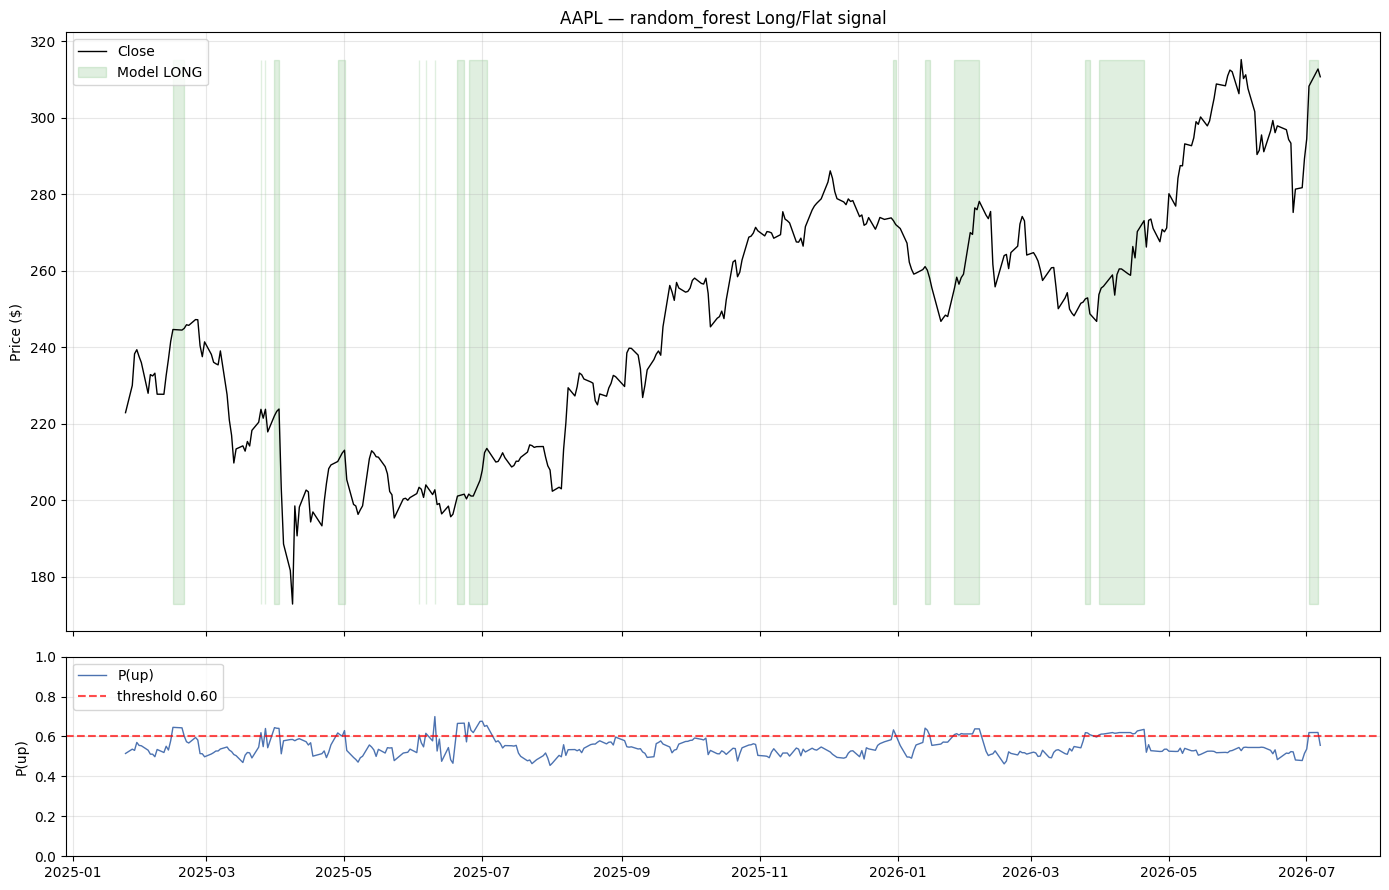

In [5]:
print(f"Model: {sm.name}")
print(f"Test window: {sm.test_index[0].date()} -> {sm.test_index[-1].date()} "
      f"({len(sm.test_index)} days)")
print(f"LONG on {int(sm.signal.sum())}/{len(sm.signal)} test days")
df_test = sm.test_frame()
fig = plot_signal(df_test, sm.proba, sm.signal, sm.threshold,
                  f"{TICKER} — {MODEL} Long/Flat signal"); plt.show()

## 5 · Backtest — ML Signal vs Buy & Hold

$100k, long-only, no leverage, no shorting. Positions act on the next bar.

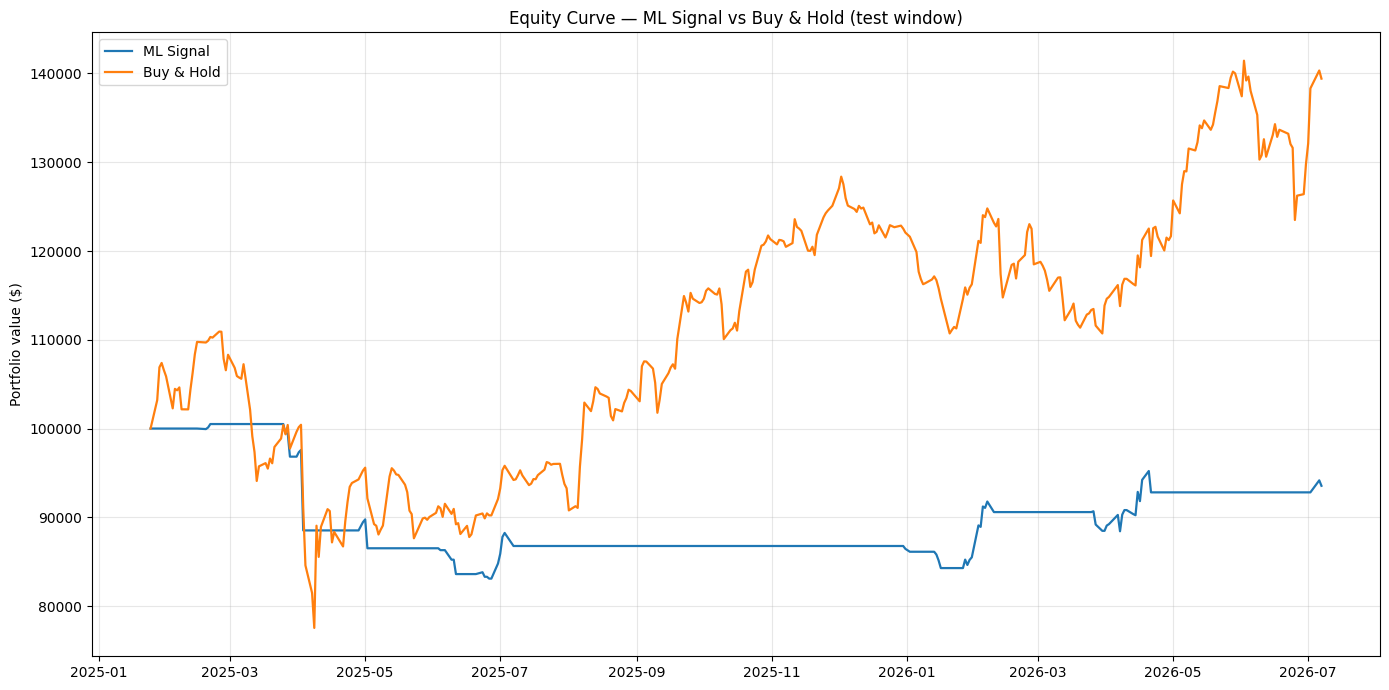

In [6]:
ml = run_backtest(df_test, sm.signal, initial_capital=100_000)
bh = run_backtest(df_test, pd.Series(1, index=df_test.index), initial_capital=100_000)
results = {"ML Signal": ml, "Buy & Hold": bh}
fig = plot_equity_curves(results); plt.show()

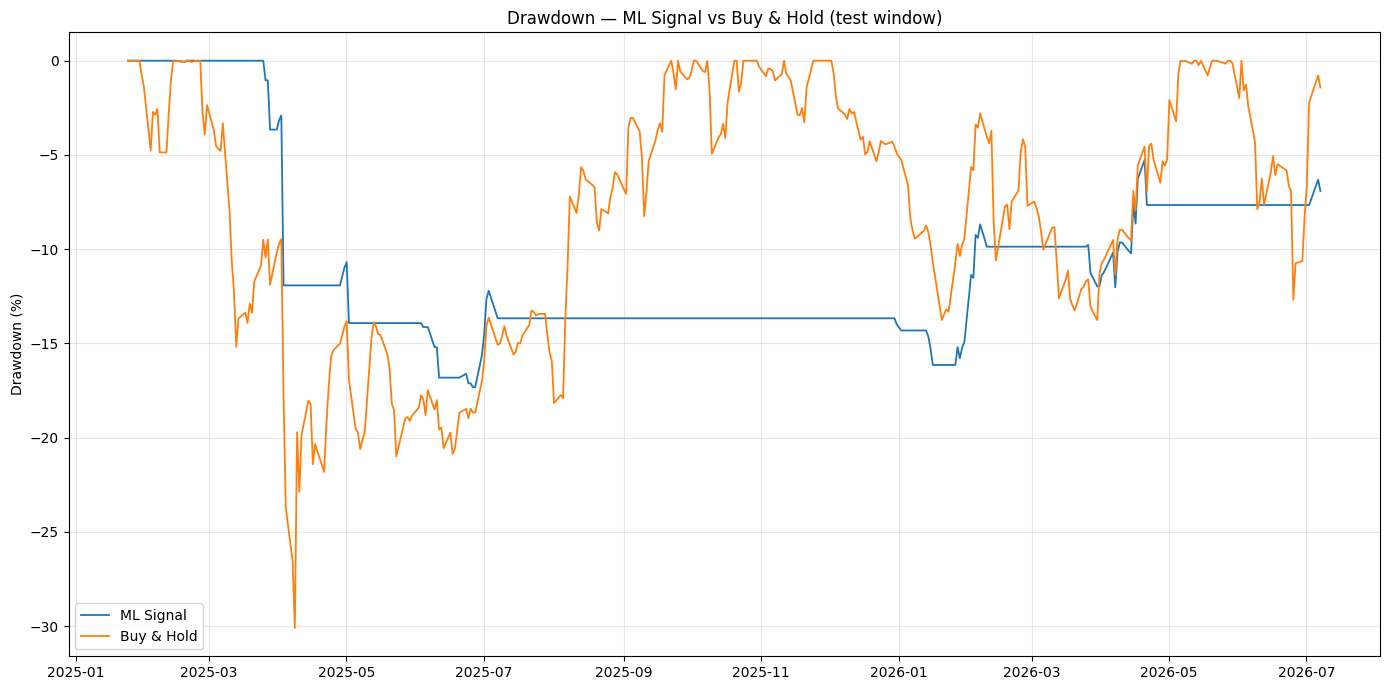

In [7]:
fig = plot_drawdowns(results); plt.show()

## 6 · Performance Metrics

Total Return, CAGR, Volatility, Sharpe, Sortino, Max Drawdown, Win Rate.

In [8]:
metrics_table(results)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Win Rate,Trades
ML Signal,-6.45%,-4.52%,11.81%,-0.33,-0.14,-17.32%,62.50%,16
Buy & Hold,39.42%,25.95%,30.32%,0.91,1.25,-30.10%,100.00%,1


## 7 · Paper Trading Demo

Run from a terminal (submits a **paper** order to Alpaca):

```bash
python paper_trade.py --ticker AAPL --qty 5           # follow the model
python paper_trade.py --ticker AAPL --qty 5 --force buy  # guarantee a demo trade
```

The script fetches the latest data, rebuilds features, applies PCA, generates
the ML signal, and submits a **BUY** (Long) or **SELL** (Flat) order to the
Alpaca paper endpoint. See the README for the dashboard screenshot + logs.

> ⚠️ **PAPER TRADING ONLY — no real money is used.**